<a href="https://colab.research.google.com/github/rachitt-t/capstone-project_sem8/blob/main/electra_n_roberta_model_capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers torch pandas
!pip install transformers datasets accelerate

In [ ]:
import pandas as pd
from transformers import pipeline

# -----------------------------
# Load your dataset
# -----------------------------
df = pd.read_csv("/content/final_2600_dataset.csv")

# -----------------------------
# Load sentiment model
# -----------------------------
classifier = pipeline("sentiment-analysis")

# -----------------------------
# Generate sentiments
# -----------------------------
# (handles all rows)
results = classifier(df["dialogue"].tolist())

# -----------------------------
# Add sentiment column
# -----------------------------
df["sentiment"] = [r["label"].upper() for r in results]

# -----------------------------
# Optional: Normalize labels to 3 classes
# -----------------------------
def normalize_sentiment(label):
    if "POS" in label:
        return "POSITIVE"
    elif "NEG" in label:
        return "NEGATIVE"
    else:
        return "NEUTRAL"

df["sentiment"] = df["sentiment"].apply(normalize_sentiment)

# -----------------------------
# Save updated dataset
# -----------------------------
df.to_csv("dataset_with_sentiment.csv", index=False)

# -----------------------------
# Show result
# -----------------------------
print("Done ✅")
print("Shape:", df.shape)
df.head()

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Done ✅
Shape: (2600, 3)


,character,dialogue,sentiment
0,ANATOLY,We are here.,POSITIVE
1,ANATOLY,5 MINUTES LATER: THE TWO SUBS skim over the se...,NEGATIVE
2,ANATOLY,sidescan sonar and the THRUM of big thrusters.,NEGATIVE
3,ANATOLY,6 The featureless gray clay of the bottom unro...,NEGATIVE
4,ANATOLY,"Bodine is watching the sidescan sonar display,...",NEGATIVE


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# -----------------------------
# Load dataset with sentiment
# -----------------------------
df = pd.read_csv("dataset_with_sentiment.csv")

# -----------------------------
# Encode labels
# -----------------------------
le = LabelEncoder()
df["label"] = le.fit_transform(df["sentiment"])

# -----------------------------
# Save updated dataset
# -----------------------------
df.to_csv("dataset_encoded.csv", index=False)

# -----------------------------
# Check mapping
# -----------------------------
print(dict(zip(le.classes_, le.transform(le.classes_))))
df.head()

{'NEGATIVE': np.int64(0), 'POSITIVE': np.int64(1)}


,character,dialogue,sentiment,label
0,ANATOLY,We are here.,POSITIVE,1
1,ANATOLY,5 MINUTES LATER: THE TWO SUBS skim over the se...,NEGATIVE,0
2,ANATOLY,sidescan sonar and the THRUM of big thrusters.,NEGATIVE,0
3,ANATOLY,6 The featureless gray clay of the bottom unro...,NEGATIVE,0
4,ANATOLY,"Bodine is watching the sidescan sonar display,...",NEGATIVE,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# check columns first
print(df.columns)

# create label column
le = LabelEncoder()
df["label"] = le.fit_transform(df["sentiment"])

# verify
print(df.head())

Index(['character', 'dialogue', 'sentiment', 'label'], dtype='object')
  character                                           dialogue sentiment  \
0   ANATOLY                                       We are here.  POSITIVE   
1   ANATOLY  5 MINUTES LATER: THE TWO SUBS skim over the se...  NEGATIVE   
2   ANATOLY     sidescan sonar and the THRUM of big thrusters.  NEGATIVE   
3   ANATOLY  6 The featureless gray clay of the bottom unro...  NEGATIVE   
4   ANATOLY  Bodine is watching the sidescan sonar display,...  NEGATIVE   

   label  
0      1  
1      0  
2      0  
3      0  
4      0  


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# -----------------------------
# STEP 1: Load dataset
# -----------------------------
df = pd.read_csv("/content/dataset_with_sentiment.csv")

# -----------------------------
# STEP 2: Check columns
# -----------------------------
print("Columns:", df.columns)

# -----------------------------
# STEP 3: Fix column names (strip spaces)
# -----------------------------
df.columns = df.columns.str.strip()

# -----------------------------
# STEP 4: Check again
# -----------------------------
print("Fixed Columns:", df.columns)

# -----------------------------
# STEP 5: Ensure 'sentiment' exists
# -----------------------------
if "sentiment" not in df.columns:
    raise Exception("❌ 'sentiment' column not found. Check file.")

# -----------------------------
# STEP 6: Create label column
# -----------------------------
le = LabelEncoder()
df["label"] = le.fit_transform(df["sentiment"])

print("Label column created ✅")

# -----------------------------
# STEP 7: Split dataset
# -----------------------------
X = df["dialogue"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Columns: Index(['character', 'dialogue', 'sentiment'], dtype='object')
Fixed Columns: Index(['character', 'dialogue', 'sentiment'], dtype='object')
Label column created ✅
Train size: 2080
Test size: 520


In [ ]:
from datasets import Dataset

# -----------------------------
# Convert pandas Series to Hugging Face Dataset format
# -----------------------------
train_dataset = Dataset.from_dict({
    "text": list(X_train),
    "label": list(y_train)
})

test_dataset = Dataset.from_dict({
    "text": list(X_test),
    "label": list(y_test)
})

print("Train and test datasets created ✅")

Train and test datasets created ✅


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix, mean_squared_error

def evaluate_model(y_true, y_pred, name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{name} RESULTS")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("MCC:", mcc)
    print("RMSE:", rmse)
    print("Confusion Matrix:\n", cm)

In [ ]:
!pip install transformers datasets accelerate

### ELECTRA Model Training

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding

# -----------------------------
# Load ELECTRA Tokenizer
# -----------------------------
model_name_electra = "google/electra-base-discriminator"
tokenizer_electra = AutoTokenizer.from_pretrained(model_name_electra)

def tokenize_electra(example):
    return tokenizer_electra(example["text"], truncation=True, padding="max_length")

train_dataset_electra = train_dataset.map(tokenize_electra, batched=True)
test_dataset_electra = test_dataset.map(tokenize_electra, batched=True)

# -----------------------------
# Data collator
# -----------------------------
data_collator_electra = DataCollatorWithPadding(tokenizer=tokenizer_electra)

print("ELECTRA tokenizer and data collator loaded ✅")

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/2080 [00:00<?, ? examples/s]

Map:   0%|          | 0/520 [00:00<?, ? examples/s]

ELECTRA tokenizer and data collator loaded ✅


#### ELECTRA with 3 Epochs

In [ ]:
# -----------------------------
# Load ELECTRA model
# -----------------------------
model_electra_3 = AutoModelForSequenceClassification.from_pretrained(
    model_name_electra,
    num_labels=3
)

# -----------------------------
# Training arguments (3 epochs)
# -----------------------------
training_args_electra_3 = TrainingArguments(
    output_dir="./electra_results_3",
    num_train_epochs=3,
    per_device_train_batch_size=1,  # Further reduced batch size
    per_device_eval_batch_size=1,   # Further reduced batch size
    gradient_accumulation_steps=8,  # Accumulate gradients over 8 steps
    gradient_checkpointing=True,    # Enable gradient checkpointing
    logging_dir="./electra_logs_3",
    save_strategy="no"
)

# -----------------------------
# Trainer
# -----------------------------
trainer_electra_3 = Trainer(
    model=model_electra_3,
    args=training_args_electra_3,
    train_dataset=train_dataset_electra,
    eval_dataset=test_dataset_electra,
    data_collator=data_collator_electra
)

# -----------------------------
# Train
# -----------------------------
trainer_electra_3.train()

# -----------------------------
# Predictions
# -----------------------------
y_pred_electra_3 = trainer_electra_3.predict(test_dataset_electra).predictions.argmax(axis=1)

print("ELECTRA (3 epochs) DONE ✅")

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Step,Training Loss
500,4.046548


ELECTRA (3 epochs) DONE ✅


#### ELECTRA with 5 Epochs

In [ ]:
# -----------------------------
# Reload ELECTRA model (fresh training)
# -----------------------------
model_electra_5 = AutoModelForSequenceClassification.from_pretrained(
    model_name_electra,
    num_labels=3
)

# -----------------------------
# Training arguments (5 epochs)
# -----------------------------
training_args_electra_5 = TrainingArguments(
    output_dir="./electra_results_5",
    num_train_epochs=5,
    per_device_train_batch_size=1,  # Reduced batch size to 1
    per_device_eval_batch_size=1,   # Reduced batch size to 1
    gradient_accumulation_steps=8,  # Accumulate gradients over 8 steps
    gradient_checkpointing=True,    # Enable gradient checkpointing
    logging_dir="./electra_logs_5",
    save_strategy="no"
)

# -----------------------------
# Trainer
# -----------------------------
trainer_electra_5 = Trainer(
    model=model_electra_5,
    args=training_args_electra_5,
    train_dataset=train_dataset_electra,
    eval_dataset=test_dataset_electra,
    data_collator=data_collator_electra
)

# -----------------------------
# Train
# -----------------------------
trainer_electra_5.train()

# -----------------------------
# Predictions
# -----------------------------
y_pred_electra_5 = trainer_electra_5.predict(test_dataset_electra).predictions.argmax(axis=1)

print("ELECTRA (5 epochs) DONE ✅")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

Step,Training Loss
500,4.527131
1000,2.987470


ELECTRA (5 epochs) DONE ✅


#### ELECTRA with 7 Epochs

In [ ]:
# -----------------------------
# Reload ELECTRA model (fresh training)
# -----------------------------
model_electra_7 = AutoModelForSequenceClassification.from_pretrained(
    model_name_electra,
    num_labels=3
)

# -----------------------------
# Training arguments (7 epochs)
# -----------------------------
training_args_electra_7 = TrainingArguments(
    output_dir="./electra_results_7",
    num_train_epochs=7,
    per_device_train_batch_size=1,  # Reduced batch size to 1
    per_device_eval_batch_size=1,   # Reduced batch size to 1
    gradient_accumulation_steps=8,  # Accumulate gradients over 8 steps
    gradient_checkpointing=True,    # Enable gradient checkpointing
    fp16=True,                      # Enable mixed precision training to save memory
    logging_dir="./electra_logs_7",
    save_strategy="no"
)

# -----------------------------
# Trainer
# -----------------------------
trainer_electra_7 = Trainer(
    model=model_electra_7,
    args=training_args_electra_7,
    train_dataset=train_dataset_electra,
    eval_dataset=test_dataset_electra,
    data_collator=data_collator_electra
)

# -----------------------------
# Train
# -----------------------------
trainer_electra_7.train()

# -----------------------------
# Predictions
# -----------------------------
y_pred_electra_7 = trainer_electra_7.predict(test_dataset_electra).predictions.argmax(axis=1)

print("ELECTRA (7 epochs) DONE ✅")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

Step,Training Loss
500,4.537822
1000,3.090115
1500,1.163217


ELECTRA (7 epochs) DONE ✅


### ELECTRA Results

In [ ]:
evaluate_model(y_test, y_pred_electra_3, "ELECTRA - 3 Epochs")
evaluate_model(y_test, y_pred_electra_5, "ELECTRA - 5 Epochs")
evaluate_model(y_test, y_pred_electra_7, "ELECTRA - 7 Epochs")


ELECTRA - 3 Epochs RESULTS
Accuracy: 0.8
Precision: 0.800803029611717
Recall: 0.8
F1 Score: 0.7989425618841625
MCC: 0.596783168199109
RMSE: 0.4472135954999579
Confusion Matrix:
 [[176  63]
 [ 41 240]]

ELECTRA - 5 Epochs RESULTS
Accuracy: 0.7865384615384615
Precision: 0.7872767187734293
Recall: 0.7865384615384615
F1 Score: 0.7853395322626091
MCC: 0.5694555257173589
RMSE: 0.4620189806290846
Confusion Matrix:
 [[172  67]
 [ 44 237]]

ELECTRA - 7 Epochs RESULTS
Accuracy: 0.8211538461538461
Precision: 0.8210370776150386
Recall: 0.8211538461538461
F1 Score: 0.8208473088455837
MCC: 0.6393332022912649
RMSE: 0.42290206176626033
Confusion Matrix:
 [[188  51]
 [ 42 239]]


### RoBERTa Model Training (Re-run)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from datasets import Dataset

# -----------------------------
# Prepare datasets
# -----------------------------
train_dataset_roberta = Dataset.from_dict({
    "text": list(X_train),
    "label": list(y_train)
})

test_dataset_roberta = Dataset.from_dict({
    "text": list(X_test),
    "label": list(y_test)
})

# -----------------------------
# Load RoBERTa Tokenizer
# -----------------------------
model_name_roberta = "roberta-base"
tokenizer_roberta = AutoTokenizer.from_pretrained(model_name_roberta)

def tokenize_roberta(example):
    return tokenizer_roberta(example["text"], truncation=True, padding="max_length")

train_dataset_roberta = train_dataset_roberta.map(tokenize_roberta, batched=True)
test_dataset_roberta = test_dataset_roberta.map(tokenize_roberta, batched=True)

# -----------------------------
# Data collator
# -----------------------------
data_collator_roberta = DataCollatorWithPadding(tokenizer=tokenizer_roberta)

print("RoBERTa tokenizer and data collator loaded ✅")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/2080 [00:00<?, ? examples/s]

Map:   0%|          | 0/520 [00:00<?, ? examples/s]

RoBERTa tokenizer and data collator loaded ✅


#### RoBERTa with 3 Epochs

In [ ]:
# -----------------------------
# Load RoBERTa model
# -----------------------------
model_roberta_3 = AutoModelForSequenceClassification.from_pretrained(
    model_name_roberta,
    num_labels=2 # Corrected from 3 to 2
)

# -----------------------------
# Training arguments (3 epochs)
# -----------------------------
training_args_roberta_3 = TrainingArguments(
    output_dir="./roberta_results_3",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir="./roberta_logs_3",
    save_strategy="no"
)

# -----------------------------
# Trainer
# -----------------------------
trainer_roberta_3 = Trainer(
    model=model_roberta_3,
    args=training_args_roberta_3,
    train_dataset=train_dataset_roberta,
    eval_dataset=test_dataset_roberta,
    data_collator=data_collator_roberta
)

# -----------------------------
# Train
# -----------------------------
trainer_roberta_3.train()

# -----------------------------
# Predictions
# -----------------------------
y_pred_roberta_3 = trainer_roberta_3.predict(test_dataset_roberta).predictions.argmax(axis=1)

print("RoBERTa (3 epochs) DONE ✅")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss
500,0.573325


RoBERTa (3 epochs) DONE ✅


#### RoBERTa with 5 Epochs

In [ ]:
# -----------------------------
# Reload RoBERTa model (fresh training)
# -----------------------------
model_roberta_5 = AutoModelForSequenceClassification.from_pretrained(
    model_name_roberta,
    num_labels=2 # Corrected from 3 to 2
)

# -----------------------------
# Training arguments (5 epochs)
# -----------------------------
training_args_roberta_5 = TrainingArguments(
    output_dir="./roberta_results_5",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir="./roberta_logs_5",
    save_strategy="no"
)

# -----------------------------
# Trainer
# -----------------------------
trainer_roberta_5 = Trainer(
    model=model_roberta_5,
    args=training_args_roberta_5,
    train_dataset=train_dataset_roberta,
    eval_dataset=test_dataset_roberta,
    data_collator=data_collator_roberta
)

# -----------------------------
# Train
# -----------------------------
trainer_roberta_5.train()

# -----------------------------
# Predictions
# -----------------------------
y_pred_roberta_5 = trainer_roberta_5.predict(test_dataset_roberta).predictions.argmax(axis=1)

print("RoBERTa (5 epochs) DONE ✅")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss


KeyboardInterrupt: 

#### RoBERTa with 7 Epochs

In [ ]:
# -----------------------------
# Reload RoBERTa model (fresh training)
# -----------------------------
model_roberta_7 = AutoModelForSequenceClassification.from_pretrained(
    model_name_roberta,
    num_labels=2 # Corrected from 3 to 2
)

# -----------------------------
# Training arguments (7 epochs)
# -----------------------------
training_args_roberta_7 = TrainingArguments(
    output_dir="./roberta_results_7",
    num_train_epochs=7,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir="./roberta_logs_7",
    save_strategy="no"
)

# -----------------------------
# Trainer
# -----------------------------
trainer_roberta_7 = Trainer(
    model=model_roberta_7,
    args=training_args_roberta_7,
    train_dataset=train_dataset_roberta,
    eval_dataset=test_dataset_roberta,
    data_collator=data_collator_roberta
)

# -----------------------------
# Train
# -----------------------------
trainer_roberta_7.train()

# -----------------------------
# Predictions
# -----------------------------
y_pred_roberta_7 = trainer_roberta_7.predict(test_dataset_roberta).predictions.argmax(axis=1)

print("RoBERTa (7 epochs) DONE ✅")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss
500,0.657781


Step,Training Loss
500,0.657781
1000,0.458582
1500,0.226319


RoBERTa (7 epochs) DONE ✅


### RoBERTa Results

In [ ]:
evaluate_model(y_test, y_pred_roberta_3, "RoBERTa - 3 Epochs")
evaluate_model(y_test, y_pred_roberta_5, "RoBERTa - 5 Epochs")
evaluate_model(y_test, y_pred_roberta_7, "RoBERTa - 7 Epochs")


RoBERTa - 3 Epochs RESULTS
Accuracy: 0.801923076923077
Precision: 0.8017845423622281
Recall: 0.801923076923077
F1 Score: 0.8014915271095412
MCC: 0.6004169662903989
RMSE: 0.4450583367120799
Confusion Matrix:
 [[182  57]
 [ 46 235]]

RoBERTa - 5 Epochs RESULTS
Accuracy: 0.825
Precision: 0.824846841192995
Recall: 0.825
F1 Score: 0.8248466577923943
MCC: 0.6472717145094427
RMSE: 0.4183300132670378
Confusion Matrix:
 [[191  48]
 [ 43 238]]

RoBERTa - 7 Epochs RESULTS
Accuracy: 0.7865384615384615
Precision: 0.7870279645926709
Recall: 0.7865384615384615
F1 Score: 0.7854784887297995
MCC: 0.5693428069783585
RMSE: 0.4620189806290846
Confusion Matrix:
 [[173  66]
 [ 45 236]]


all models comparison

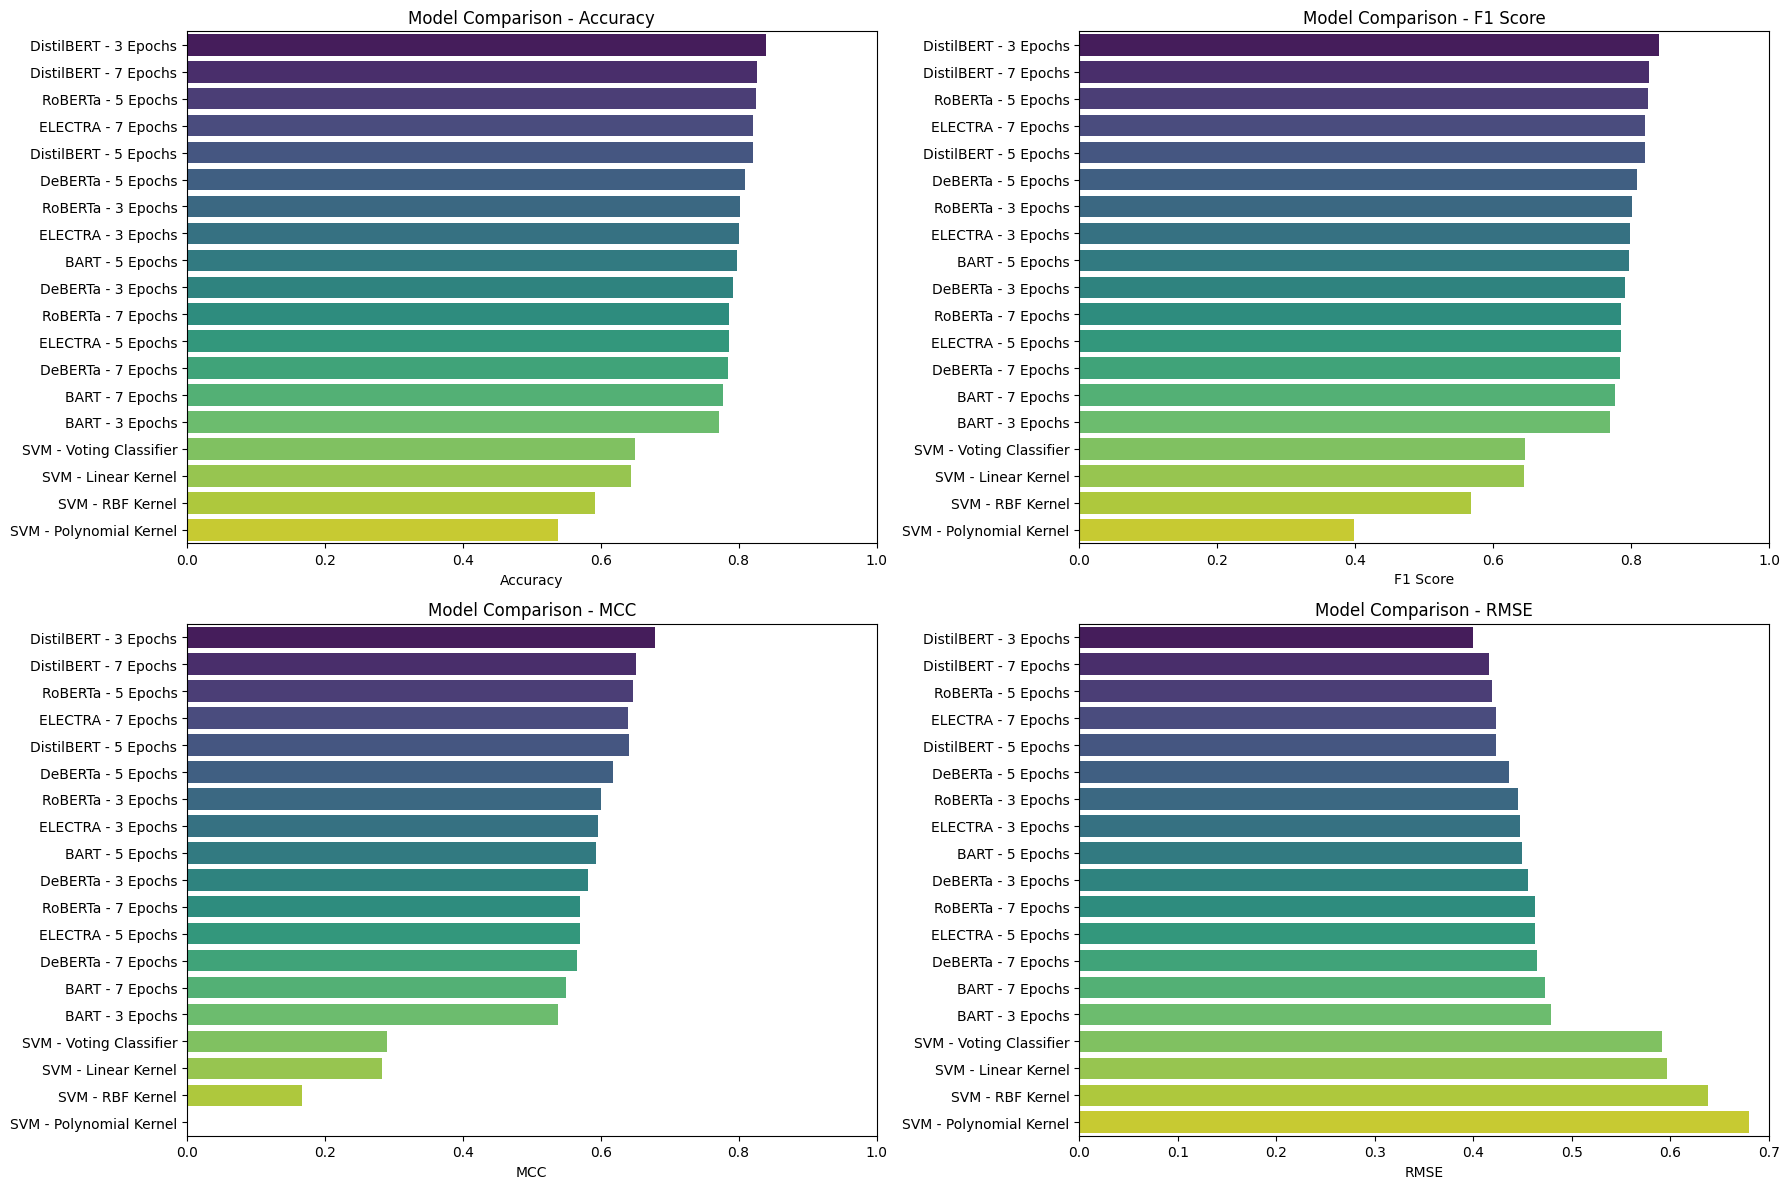

Model comparison graphs generated ✅


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data for BART models
bart_data = {
    "Model": ["BART - 3 Epochs", "BART - 5 Epochs", "BART - 7 Epochs"],
    "Accuracy": [0.7711538461538462, 0.7980769230769231, 0.7769230769230769],
    "Precision": [0.7728735207100591, 0.7982894161585437, 0.7767527162103433],
    "Recall": [0.7711538461538462, 0.7980769230769231, 0.7769230769230769],
    "F1 Score": [0.7692001098109273, 0.7973181578854086, 0.7762686965811966],
    "MCC": [0.5387637541291109, 0.5926282567542644, 0.5497571051179371],
    "RMSE": [0.47837867202264966, 0.4493585171364586, 0.4723101979387308]
}

# Data for DeBERTa models
deberta_data = {
    "Model": ["DeBERTa - 3 Epochs", "DeBERTa - 5 Epochs", "DeBERTa - 7 Epochs"],
    "Accuracy": [0.7923076923076923, 0.8096153846153846, 0.7846153846153846],
    "Precision": [0.7943420431320245, 0.8122904339250493, 0.7854599841637585],
    "Recall": [0.7923076923076923, 0.8096153846153846, 0.7846153846153846],
    "F1 Score": [0.7906161828036827, 0.8079900073216958, 0.7833330056451044],
    "MCC": [0.581941864211242, 0.6175303848497411, 0.5656075007013708],
    "RMSE": [0.45573271518765, 0.4363308554120547, 0.4640954808922571]
}

# Data for DistilBERT models
distilbert_data = {
    "Model": ["DistilBERT - 3 Epochs", "DistilBERT - 5 Epochs", "DistilBERT - 7 Epochs"],
    "Accuracy": [0.8403846153846154, 0.8211538461538461, 0.8269230769230769],
    "Precision": [0.8407813892188891, 0.8236296230651069, 0.8268009383926338],
    "Recall": [0.8403846153846154, 0.8211538461538461, 0.8269230769230769],
    "F1 Score": [0.8398737763690544, 0.8197661252520896, 0.826664656731846],
    "MCC": [0.6783142721582107, 0.6407901971919611, 0.6510132237896609],
    "RMSE": [0.3995189414976274, 0.42290206176626033, 0.41602514716892186]
}

# Data for SVM models
svm_data = {
    "Model": ["SVM - Linear Kernel", "SVM - RBF Kernel", "SVM - Polynomial Kernel", "SVM - Voting Classifier"],
    "Accuracy": [0.6442307692307693, 0.5923076923076923, 0.5384615384615384, 0.65],
    "Precision": [0.6441216011772958, 0.5943856143856143, 0.5041723562433622, 0.6489091078615717],
    "Recall": [0.6442307692307693, 0.5923076923076923, 0.5384615384615384, 0.65],
    "F1 Score": [0.64417380397306, 0.5674550321609145, 0.3976869154534129, 0.6462817233916979],
    "MCC": [0.2835673204423471, 0.16680431044267674, 0.0006178962877914625, 0.29027984987504657],
    "RMSE": [0.596463939202724, 0.6385078759829887, 0.6793662204867574, 0.5916079783099616]
}

# Data for RoBERTa models
roberta_data = {
    "Model": ["RoBERTa - 3 Epochs", "RoBERTa - 5 Epochs", "RoBERTa - 7 Epochs"],
    "Accuracy": [0.801923076923077, 0.825, 0.7865384615384615],
    "Precision": [0.8017845423622281, 0.824846841192995, 0.7870279645926709],
    "Recall": [0.801923076923077, 0.825, 0.7865384615384615],
    "F1 Score": [0.8014915271095412, 0.8248466577923943, 0.7854784887297995],
    "MCC": [0.6004169662903989, 0.6472717145094427, 0.5693428069783585],
    "RMSE": [0.4450583367120799, 0.4183300132670378, 0.4620189806290846]
}

# Data for ELECTRA models
electra_data = {
    "Model": ["ELECTRA - 3 Epochs", "ELECTRA - 5 Epochs", "ELECTRA - 7 Epochs"],
    "Accuracy": [0.8, 0.7865384615384615, 0.8211538461538461],
    "Precision": [0.800803029611717, 0.7872767187734293, 0.8210370776150386],
    "Recall": [0.8, 0.7865384615384615, 0.8211538461538461],
    "F1 Score": [0.7989425618841625, 0.7853395322626091, 0.8208473088455837],
    "MCC": [0.596783168199109, 0.5694555257173589, 0.6393332022912649],
    "RMSE": [0.4472135954999579, 0.4620189806290846, 0.42290206176626033]
}

# Create DataFrames
df_bart = pd.DataFrame(bart_data)
df_deberta = pd.DataFrame(deberta_data)
df_distilbert = pd.DataFrame(distilbert_data)
df_svm = pd.DataFrame(svm_data)
df_roberta = pd.DataFrame(roberta_data)
df_electra = pd.DataFrame(electra_data)

# Combine all results
all_results = pd.concat(
    [df_bart, df_deberta, df_distilbert, df_svm, df_roberta, df_electra],
    ignore_index=True
)

# Sort by Accuracy
all_results_sorted = all_results.sort_values(by="Accuracy", ascending=False)

# Melt for plotting
all_results_melted = all_results_sorted.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Metrics to plot
metrics_to_plot = ["Accuracy", "F1 Score", "MCC", "RMSE"]
plot_data = all_results_melted[all_results_melted["Metric"].isin(metrics_to_plot)]

# Plot
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(
        x="Score",
        y="Model",
        hue="Model",
        data=plot_data[plot_data["Metric"] == metric],
        ax=axes[i],
        palette="viridis",
        legend=False
    )
    axes[i].set_title(f"Model Comparison - {metric}")
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel("")
    axes[i].set_xlim(0, 1)

    if metric == "RMSE":
        axes[i].set_xlim(0, 0.7)

plt.tight_layout()
plt.show()

print("Model comparison graphs generated ✅")